In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:

## generate A, B_i for the bilinear system ##

def spectral_radius(M: np.ndarray) -> float:
    """Spectral radius rho(M) = max |lambda_i(M)|."""
    return float(np.max(np.abs(np.linalg.eigvals(M))))

def make_A(n: int, rng: np.random.Generator) -> np.ndarray:
    """
    A is diagonal with max_j |a_jj| = 1.
    We force a_11 = 1 so rho(A⊗A) already has an eigenvalue at 1.
    """
    a = rng.uniform(-1.0, 1.0, size=n)
    a[0] = 1.0                       # ensure max abs = 1, and keep it exactly 1
    A = np.diag(a)
    return A

def make_B_list(n: int, m: int, rng: np.random.Generator) -> list[np.ndarray]:
    """
    Each B_i is strictly lower-triangular.
    """
    Bs = []
    for _ in range(m):
        X = rng.normal(0.0, 1.0, size=(n, n))
        B = np.tril(X, k=-1)         # strictly lower triangular
        Bs.append(B)
    return Bs

def build_tildeA(A: np.ndarray, Bs: list[np.ndarray], sigma_u2: float = 1.0) -> np.ndarray:
    """
    Mean-square lifted matrix (typical form):
        tildeA = A⊗A + sigma_u^2 * sum_i (B_i ⊗ B_i)
    """
    n = A.shape[0]
    AA = np.kron(A, A)
    S = np.zeros((n*n, n*n), dtype=float)
    for B in Bs:
        S += np.kron(B, B)
    return AA + sigma_u2 * S

def scale_Bs_to_rho1(A: np.ndarray, Bs: list[np.ndarray], sigma_u2: float = 1.0,
                     tol: float = 1e-10, max_iter: int = 80) -> tuple[list[np.ndarray], float, float]:
    """
    Scale all B_i by a common factor alpha so that rho(tildeA) is (numerically) 1.
    Because we forced B_i e1 = 0, the eigenvalue 1 from A⊗A is preserved,
    so making all other eigenvalues <= 1 yields rho(tildeA) = 1.
    """
    n = A.shape[0]
    AA = np.kron(A, A)

    # Precompute S0 = sum kron(Bi0, Bi0)
    S0 = np.zeros((n*n, n*n), dtype=float)
    for B in Bs:
        S0 += np.kron(B, B)

    # If already okay, return
    rho0 = spectral_radius(AA + sigma_u2 * S0)
    if rho0 <= 1.0 + tol:
        return Bs, 1.0, rho0
    else:
        print('False')

# =========================
# Main: generate A, {B_i}
# =========================
n = 5
m = 4
seed = 0
rng = np.random.default_rng(seed)

A = make_A(n, rng)
Bs = make_B_list(n, m, rng)

# If your model uses Var(u_{t,i}) = 1 (before truncation), you can set sigma_u2 = 1.
sigma_u2 = 1.0

Bs, alpha, rho_tilde = scale_Bs_to_rho1(A, Bs, sigma_u2=2)

print("max |a_jj| =", np.max(np.abs(np.diag(A))))
print("rho(tildeA) =", rho_tilde)

# Sanity checks
for i, B in enumerate(Bs, 1):
    is_strict_lower = np.allclose(B, np.tril(B, k=-1))
    print(f"B_{i} strictly lower-triangular:", is_strict_lower)


# A = A/1.5
# Bs = [x / 1.5 for x in Bs]

max |a_jj| = 1.0
rho(tildeA) = 1.0
B_1 strictly lower-triangular: True
B_2 strictly lower-triangular: True
B_3 strictly lower-triangular: True
B_4 strictly lower-triangular: True


In [3]:
## Generate input U and noise W ##
# U: (T,m)
# W: (T,n)

def sample_truncated_gaussian_linf(T: int, m: int, bound: float = 2.0, seed: int | None = None):
    """
    u_t ~ N(0, I_m) truncated to {u: ||u||_inf <= bound}, i.i.d. across t.
    Returns U with shape (T, m).
    """
    rng = np.random.default_rng(seed)
    U = np.empty((T, m), dtype=float)
    filled = 0

    batch = max(1024, 4 * T)
    while filled < T:
        X = rng.standard_normal(size=(batch, m))  # N(0, I)
        keep_mask = np.max(np.abs(X), axis=1) <= bound
        keep = X[keep_mask]
        k = min(keep.shape[0], T - filled)
        if k > 0:
            U[filled:filled + k] = keep[:k]
            filled += k

    return U

def sample_truncated_laplace_linf(T: int, n: int, bound: float = 2.0, seed: int | None = None):
    """
    w_t ~ Lap(0, 1) (i.i.d. per coordinate) truncated to {w: ||w||_inf <= bound}, i.i.d. across t.
    Returns W with shape (T, n).
    """
    rng = np.random.default_rng(seed)
    W = np.empty((T, n), dtype=float)
    filled = 0

    batch = max(1024, 4 * T)
    while filled < T:
        X = rng.laplace(loc=0.0, scale=1.0, size=(batch, n))  # component-wise Laplace(0,1)
        keep_mask = np.max(np.abs(X), axis=1) <= bound
        keep = X[keep_mask]
        k = min(keep.shape[0], T - filled)
        if k > 0:
            W[filled:filled + k] = keep[:k]
            filled += k

    return W

# ===== usage =====
T = 20000
U = sample_truncated_gaussian_linf(T, m, bound=2.0, seed=1)

# W = sample_truncated_laplace_linf(T, n, bound=2.0, seed=2)
W = sample_truncated_gaussian_linf(T, n, bound=1.0, seed=2)
# W = np.zeros((T,n))
# W[0,:] = np.ones(n)
   


print(np.max(np.abs(U)), np.max(np.abs(W)))  # should be <= 2.0/1.0


1.9998224959527664 0.9999978905581786


In [4]:
import numpy as np
import cvxpy as cp

# =========================
# 1) simulate trajectory X
# =========================
def simulate_bilinear(A, B_list, U, W, x0=None):
    """
    x_{t+1} = A x_t + sum_{i=1}^m u_{t,i} B_i x_t + w_t
    A: (n,n), B_list: list of m (n,n), U: (T,m), W: (T,n)
    return X: (T+1,n)
    """
    T, m = U.shape
    n = A.shape[0]
    assert W.shape == (T, n)
    assert len(B_list) == m

    if x0 is None:
        x0 = np.zeros(n)
    x0 = np.asarray(x0).reshape(n,)

    X = np.zeros((T + 1, n), dtype=float)
    X[0] = x0

    for t in range(T):
        x_t = X[t]
        bil = np.zeros(n, dtype=float)
        for i in range(m):
            bil += U[t, i] * (B_list[i] @ x_t)
        X[t + 1] = A @ x_t + bil + W[t]
    return X

# =========================
# 2) build z_t = [x_t; u_t ⊗ x_t]
# =========================
def build_Z(X, U):
    """
    X: (T+1,n), U:(T,m) -> Z:(T, n+m*n)
    z_t = [x_t ; kron(u_t, x_t)]
    """
    T, m = U.shape
    n = X.shape[1]
    assert X.shape[0] == T + 1

    Z = np.zeros((T, n + m * n), dtype=float)
    for t in range(T):
        x_t = X[t]
        u_t = U[t]
        Z[t, :n] = x_t
        Z[t, n:] = np.kron(u_t, x_t)
    return Z

def theta_true_from_A_B(A, B_list):
    """Theta_* = [A, B1, ..., Bm]  (n, n+m*n)"""
    return np.hstack([A] + B_list)

# =========================
# 3) SME point estimate: min Frobenius feasible point
# =========================
def identify_theta_min_fro(X, U, w_max=1.0, solver="OSQP", verbose=True):
    """
    min ||Theta||_F^2
    s.t. ||x_{t+1} - Theta z_t||_inf <= w_max, for all t
    """
    T, m = U.shape
    n = X.shape[1]
    Z = build_Z(X, U)      # (T, d)
    Y = X[1:]              # (T, n)
    d = Z.shape[1]

    Theta = cp.Variable((n, d))
    resid = Y - cp.transpose(Theta @ Z.T)  # (T, n)

    constraints = [resid <= w_max, resid >= -w_max]
    prob = cp.Problem(cp.Minimize(cp.sum_squares(Theta)), constraints)
    prob.solve(solver=solver, verbose=verbose)

    if Theta.value is None:
        raise RuntimeError(f"Solver failed: status={prob.status}")

    Theta_hat = Theta.value
    max_abs_resid = float(np.max(np.abs(Y - (Z @ Theta_hat.T))))
    return Theta_hat, {"status": prob.status, "obj": float(prob.value), "max_abs_resid": max_abs_resid}

def identify_theta_min_fro_scaled(X, U, w_max=1.0, solver=cp.GUROBI, verbose=True, eps=1e-13):
    """
    min ||Theta||_F^2
    s.t. || (x_{t+1}/s_t) - Theta (z_t/s_t) ||_inf <= w_max/s_t, for all t
    where s_t = 1 + ||z_t||_2 (default).
    """
    T, m = U.shape
    n = X.shape[1]
    Z = build_Z(X, U)      # (T, d)
    Y = X[1:]              # (T, n)
    d = Z.shape[1]

    # --- per-time scaling ---
    s = 1.0 + np.linalg.norm(Z, axis=1)          # (T,)
    s = np.maximum(s, eps)

    Zs = Z / s[:, None]                           # (T, d)
    Ys = Y / s[:, None]                           # (T, n)
    w_vec = (w_max / s).reshape(T, 1)             # (T, 1) broadcast to (T,n)

    Theta = cp.Variable((n, d))
    resid = Ys - cp.transpose(Theta @ Zs.T)       # (T, n)

    constraints = [resid <= w_vec, resid >= -w_vec]
    prob = cp.Problem(cp.Minimize(cp.sum_squares(Theta)), constraints)
    prob.solve(solver=solver, verbose=verbose, NumericFocus=3, FeasibilityTol=1e-9,
        OptimalityTol=1e-9)

    if Theta.value is None:
        raise RuntimeError(f"Solver failed: status={prob.status}")

    Theta_hat = Theta.value

    # diagnostics on ORIGINAL (unscaled) residuals
    max_abs_resid = float(np.max(np.abs(Y - (Z @ Theta_hat.T))))
    # diagnostics on SCALED residuals (should be <= w_max/s_t)
    max_abs_resid_scaled = float(np.max(np.abs(Ys - (Zs @ Theta_hat.T)) / (w_max / s)[:, None]))

    return Theta_hat, {
        "status": prob.status,
        "obj": float(prob.value),
        "max_abs_resid": max_abs_resid,
        "max_scaled_violation_ratio": max_abs_resid_scaled,  # <= 1 means feasible
        "s_min": float(np.min(s)),
        "s_max": float(np.max(s)),
    }

def identify_theta_cheb_inf_center(
    X, U,
    w_max=1.0,
    per_time_scaling=True,   # True: 用 s_t 缩放（推荐）
    solver=cp.GUROBI,
    verbose=False,
    eps=1e-12,
):
    """
    ℓ∞-Chebyshev center of SME polytope:
      maximize r
      s.t.  Ys - w_vec + r*||z_s||_1 <= (Theta z_s) <= Ys + w_vec - r*||z_s||_1
    This is an LP in (Theta, r).
    """
    T, m = U.shape
    n = X.shape[1]
    Z = build_Z(X, U)   # (T, d)
    Y = X[1:]           # (T, n)
    d = Z.shape[1]

    if per_time_scaling:
        s = 1.0 + np.linalg.norm(Z, axis=1)
        s = np.maximum(s, eps)
        Zs = Z / s[:, None]
        Ys = Y / s[:, None]
        w_vec = (w_max / s)[:, None]       # (T,1)
    else:
        Zs, Ys = Z, Y
        w_vec = w_max * np.ones((T, 1))

    zL1 = np.sum(np.abs(Zs), axis=1)[:, None]   # (T,1) = ||z_t||_1

    Theta = cp.Variable((n, d))
    r = cp.Variable(nonneg=True)

    P = cp.transpose(Theta @ Zs.T)  # (T,n) prediction

    constraints = [
        P <= Ys + w_vec - r * zL1,
        P >= Ys - w_vec + r * zL1,
    ]

    prob = cp.Problem(cp.Maximize(r), constraints)
    prob.solve(solver=solver, verbose=verbose)

    if Theta.value is None:
        raise RuntimeError(f"Solver failed: status={prob.status}")

    Theta_c = Theta.value
    r_star = float(r.value)

    # diagnostics: scaled feasibility margin ratio
    # should be <= 1 in absolute if feasible; here just report max residual
    max_abs_resid = float(np.max(np.abs(Y - (Z @ Theta_c.T))))

    return Theta_c, {"status": prob.status, "r": r_star, "max_abs_resid": max_abs_resid}

# =========================
# 4) End-to-end: run everything + report norms
# =========================
def run_identification(A, B_list, U, W, x0=None, w_max=1.0, solver=cp.GUROBI, verbose=False):
    X = simulate_bilinear(A, B_list, U, W, x0=x0)
    # Theta_hat, info = identify_theta_min_fro(X, U, w_max=w_max, solver=solver, verbose=verbose)
    # Theta_hat, info = identify_theta_min_fro_scaled(X, U, w_max=w_max, solver=solver, verbose=verbose)
    Theta_hat, info = identify_theta_cheb_inf_center(X, U, w_max=1.0, per_time_scaling=True,
                                                 solver=cp.GUROBI, verbose=False)

    Theta_true = theta_true_from_A_B(A, B_list)

    err = float(np.linalg.norm(Theta_hat - Theta_true, ord="fro"))
    tru = float(np.linalg.norm(Theta_true, ord="fro"))
    rel = err / (tru + 1e-12)

    print("=== SME (min Fro) ===")
    print("solver status:", info["status"])
    # print("objective    :", info["obj"])
    print("max |resid|  :", info["max_abs_resid"], "(should be <= w_max =", w_max, ")")
    print("||Theta_hat - Theta_true||_F =", err)
    print("||Theta_true||_F             =", tru)
    print("relative error               =", rel)

    return X, Theta_hat, Theta_true, info

# =========================
# You already have: A, Bs (list), U, W
# Just run:
X, Theta_hat, Theta_true, info = run_identification(A, Bs, U, W, x0=np.zeros(n), w_max=1.0)
# X = simulate_bilinear(A, Bs, U, W, x0=np.zeros(n))
# =========================

Set parameter Username
Academic license - for non-commercial use only - expires 2027-03-16
=== SME (min Fro) ===
solver status: optimal
max |resid|  : 0.9999755221891533 (should be <= w_max = 1.0 )
||Theta_hat - Theta_true||_F = 0.00021890756609227712
||Theta_true||_F             = 5.89448951675919
relative error               = 3.7137663146205084e-05


In [5]:
## 算SME可行域的直径：F-norm ##
def identify_theta_sme_diameter_fro(
    X, U,
    w_max=1.0,
    per_time_scaling=True,
    theta_bound=None,          # float or None. If set, enforces |Theta_ij| <= theta_bound to keep set bounded.
    n_samp=None,               # number of random directions (not counting the negative copies)
    solver=cp.GUROBI,
    verbose=False,
    eps=1e-12,
    Z_dirs=None,               # optional custom directions, shape (K, n*d) or (K, n, d)
    return_points=False,
):
    """
    Approximate Frobenius-norm diameter of the SME feasible set:
        S_T = {Theta: ||Y - (Theta z_t)||_inf <= w_max  for all t}
    (with optional per-time scaling as in identify_theta_cheb_inf_center).

    We approximate diam_F(S_T) = max_{Theta1,Theta2 in S_T} ||Theta1-Theta2||_F
    by sampling directions D_k and solving LPs:
        max <Theta, D_k>   s.t. Theta in S_T
    Collect the maximizers {Theta_k} and return max pairwise Frobenius distance among them.

    Notes:
    - If the feasible set is unbounded (can happen if Z is rank-deficient), the diameter is infinite.
      In that case, set `theta_bound` to a reasonable box bound to make the diameter finite/computable.
    """
    T, m = U.shape
    n = X.shape[1]
    Z = build_Z(X, U)     # (T, d)
    Y = X[1:]             # (T, n)
    d = Z.shape[1]

    # Same scaling convention as your Chebyshev-center LP
    if per_time_scaling:
        s = 1.0 + np.linalg.norm(Z, axis=1)
        s = np.maximum(s, eps)
        Zs = Z / s[:, None]
        Ys = Y / s[:, None]
        w_vec = (w_max / s)[:, None]  # (T,1)
    else:
        Zs, Ys = Z, Y
        w_vec = w_max * np.ones((T, 1))

    Theta = cp.Variable((n, d))

    # SME feasibility constraints (no Cheb radius here)
    P = cp.transpose(Theta @ Zs.T)  # (T,n)
    constraints = [
        P <= Ys + w_vec,
        P >= Ys - w_vec,
    ]

    # Optional box bound to prevent unbounded diameter when Z is rank-deficient
    if theta_bound is not None:
        constraints += [Theta <= theta_bound, Theta >= -theta_bound]

    # Build directions
    Ddim = n * d
    if Z_dirs is not None:
        if Z_dirs.ndim == 3:
            D_list = Z_dirs.reshape(Z_dirs.shape[0], Ddim)
        else:
            D_list = Z_dirs
        D_list = np.asarray(D_list, dtype=float)
    else:
        if n_samp is None:
            n_samp = 18 * Ddim  # similar spirit to the CDC script
        G = np.random.randn(n_samp, Ddim)
        G /= (np.linalg.norm(G, axis=1, keepdims=True) + 1e-18)
        D_list = G

    # Include both directions (+D and -D) so we sample both "sides"
    D_list = np.vstack([D_list, -D_list])  # (K, Ddim)
    K = D_list.shape[0]

    # Solve support LPs
    Theta_vecs = np.zeros((K, Ddim), dtype=float)
    support_vals = np.zeros((K,), dtype=float)

    # Reuse the same constraint list; only objective changes per direction
    for k in range(K):
        Dk = D_list[k].reshape(n, d)
        obj = cp.Maximize(cp.sum(cp.multiply(Theta, Dk)))
        prob = cp.Problem(obj, constraints)
        prob.solve(solver=solver, verbose=verbose)

        if prob.status in ("infeasible", "infeasible_inaccurate"):
            raise RuntimeError(f"SME set infeasible (status={prob.status}). Check w_max / scaling.")
        if prob.status in ("unbounded", "unbounded_inaccurate"):
            raise RuntimeError(
                "SME set appears unbounded in the optimized direction. "
                "Diameter is infinite unless you add bounds (set theta_bound=...)."
            )
        if Theta.value is None:
            raise RuntimeError(f"Solver failed (status={prob.status}).")

        Theta_k = Theta.value
        Theta_vecs[k] = Theta_k.reshape(-1)
        support_vals[k] = float(prob.value)

    # Compute max pairwise Frobenius distance among sampled extreme points
    # distance^2(i,j) = ||vi||^2 + ||vj||^2 - 2 vi·vj
    norms2 = np.sum(Theta_vecs**2, axis=1)                 # (K,)
    Gm = Theta_vecs @ Theta_vecs.T                         # (K,K)
    dist2 = norms2[:, None] + norms2[None, :] - 2.0 * Gm   # (K,K)
    # numerical floor
    dist2 = np.maximum(dist2, 0.0)
    diam = float(np.sqrt(np.max(dist2)))

    info = {
        "K": int(K),
        "n": int(n),
        "d": int(d),
        "per_time_scaling": bool(per_time_scaling),
        "theta_bound": None if theta_bound is None else float(theta_bound),
        "support_vals_min": float(np.min(support_vals)),
        "support_vals_max": float(np.max(support_vals)),
    }

    if return_points:
        # return the sampled extreme points (as Theta matrices) too
        Thetas = Theta_vecs.reshape(K, n, d)
        return diam, info, Thetas, D_list.reshape(K, n, d)
    return diam, info

ttest = 220
X_T = X[:ttest+1]
U_T = U[:ttest]
W_T = W[:ttest]
diam_SME_T, info_d = identify_theta_sme_diameter_fro(X_T, U_T, w_max=1.0, n_samp=100, per_time_scaling=True, theta_bound=100.0)
print(diam_SME_T, info_d)

0.3275472396138286 {'K': 200, 'n': 5, 'd': 25, 'per_time_scaling': True, 'theta_bound': 100.0, 'support_vals_min': -1.223080047673054, 'support_vals_max': 1.362566183197259}


In [ ]:
import matplotlib.pyplot as plt

tlen = 500
Tlist = list(range(10, tlen+1, 5))
errs = []

Theta_true = theta_true_from_A_B(A, Bs)   # (n, n+mn)
n = A.shape[0]
x0 = np.zeros(n)

totallst = [tlen*i for i in range(10)]


totalerr=[]


for b in totallst:
    for T in Tlist:
        U_T = U[b:b+T]
        W_T = W[b:b+T]

        # 1) simulate X
        X_T = simulate_bilinear(A, Bs, U_T, W_T, x0=x0)   # (T+1,n)
        
        diam_SME_T, info_d = identify_theta_sme_diameter_fro(X_T, U_T, w_max=1.0, n_samp=120, per_time_scaling=True, theta_bound=100.0)

        errs.append(diam_SME_T)
    errs = np.array(errs)
    totalerr.append(errs)
    errs = []


totalerr = np.array(totalerr)
# np.save("totalerr_poly_incre.npy", totalerr)
# # 保存下来（两列：T, error）
# out = np.column_stack([Tlist, errs])
# np.savetxt("theta_error_vs_T.csv", out, delimiter=",", header="T,fro_error", comments="")

# # plot
# plt.figure()
# plt.plot(Tlist, errs, marker="o")
# plt.yscale("log")
# plt.xlabel("T")
# plt.ylabel(r"$\|\hat{\Theta}-\Theta_*\|_F$")
# plt.title(r"SME: Set Diameter vs Time $T$")
# plt.grid(True, which="both")
# plt.show()

In [6]:
totalerr = np.load("totalerr_poly_incre.npy")

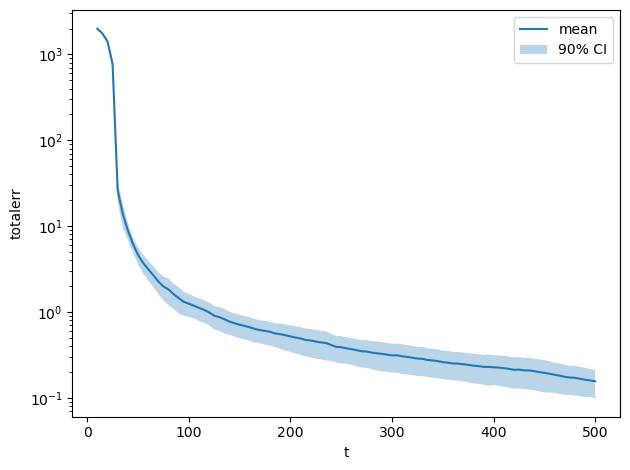

In [7]:
totalerr = np.array(totalerr)
totalerr.shape

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# totalerr: shape (n_traj=10, T=9)
n, T = totalerr.shape

# x 轴（如果你有自己的时间点数组，就替换这行）
x = list(range(10, 501, 5))

# 均值与标准误
mean = totalerr.mean(axis=0)
std = totalerr.std(axis=0, ddof=1)          # 样本标准差
sem = std / np.sqrt(n)                      # 标准误

# 90% 置信区间：alpha=0.10 -> 双侧用 1-alpha/2 = 0.95
alpha = 0.05
tcrit = t.ppf(1 - alpha/2, df=n-1)
half_width = tcrit * sem

lower = mean - half_width
upper = mean + half_width

# 画图：均值曲线 + CI 阴影带（“bar”）
plt.figure()
plt.plot(x, mean,  label='mean')
plt.fill_between(x, lower, upper, alpha=0.3, label='90% CI')

# 如果你更想要“误差棒”形式（bar），把上面 fill_between 注释掉，启用下面这行：
# plt.errorbar(x, mean, yerr=half_width, fmt='-o', capsize=4, label='mean ± 90% CI')
plt.yscale('log')
plt.xlabel('t')
plt.ylabel('totalerr')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
A, Bs

(array([[ 1.        ,  0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        , -0.46042657,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        , -0.91805295,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , -0.96694473,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.62654048]]),
 [array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
         [-0.62327446,  0.        ,  0.        ,  0.        ,  0.        ],
         [-0.73226735, -0.54425898,  0.        ,  0.        ,  0.        ],
         [-0.12853466,  1.36646347, -0.66519467,  0.        ,  0.        ],
         [ 0.0940123 , -0.74349925, -0.92172538, -0.45772583,  0.        ]]),
  array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
         [ 0.35537271,  0.        ,  0.        ,  0.        ,  0.        ],
         [-1.25906553,  1.51392377,  0.        ,  0.        ,  0.        ],
         [-0.

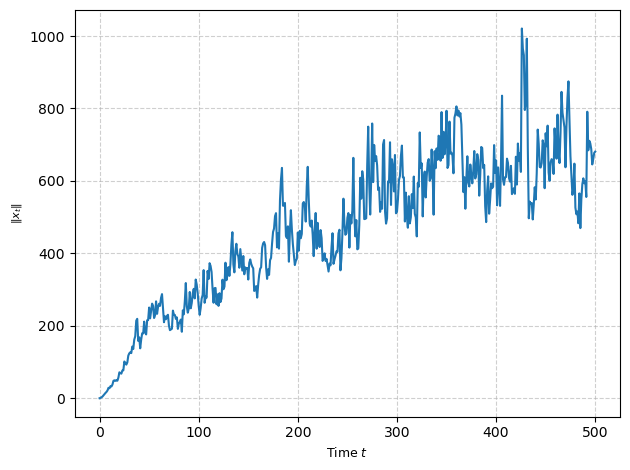

In [9]:
# simulate_bilinear(A, B_list, U, W, x0=None)

K = 39          # 轨迹条数
N = 500         # 每条轨迹长度（你改）
x0 = np.zeros(5)     # 或者给 np.zeros(n) / 你想要的初值

U_long = U      # (T_total, m)
W_long = W      # (T_total, n)

T_total = U_long.shape[0]
assert W_long.shape[0] == T_total

need = K * N
if T_total < need:
    raise ValueError(f"U/W 长度不够：T_total={T_total} < K*N={need}")

X_list = []  # 存 K 条轨迹，每条 shape (N+1, n)

for k in range(K):
    s = k * N
    e = s + N
    U_seg = U_long[s:e, :]
    W_seg = W_long[s:e, :]
    Xk = simulate_bilinear(A, Bs, U_seg, W_seg, x0=x0)
    X_list.append(Xk)

# X_list[k] 就是第 k 条轨迹 (N+1, n)
# X_list
import numpy as np
import matplotlib.pyplot as plt

# 1) 每条轨迹在每个时刻的 ||x_t||
# norms: (K, N+1)
norms = np.stack([np.linalg.norm(Xk, axis=1) for Xk in X_list], axis=0)

# 2) 对所有轨迹取均值（每个时刻平均）
mean_norm = norms.mean(axis=0)          # (N+1,)
tgrid = np.arange(norms.shape[1])       # 0..N

# （可选）也算一下标准差/置信带
std_norm = norms.std(axis=0, ddof=1)

# 3) 画 mean 曲线（可选加置信带）
plt.figure()
plt.rcParams['figure.figsize'] = [4.5, 3.5]
plt.plot(tgrid, mean_norm)
# 可选：画 ±1 std 带
# plt.fill_between(tgrid, mean_norm-std_norm, mean_norm+std_norm, alpha=0.25, label=r"$\pm 1$ std")

plt.xlabel("Time $t$",fontsize=9)
plt.ylabel(r"$\|x_t\|$",fontsize=8)
plt.grid(True, which="both", linestyle="--", alpha=0.6)
# plt.legend()
plt.tight_layout()
plt.savefig('norm_state.pdf')
plt.show()

In [10]:
A

array([[ 1.        ,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        , -0.46042657,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        , -0.91805295,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , -0.96694473,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.62654048]])

In [11]:
# =========================
# 4) OLS point estimate (closed-form)
# =========================
# def identify_theta_ols(X, U, ridge=0.0, use_pinv_if_singular=True):
#     """
#     OLS:
#         Theta_OLS = argmin_Theta 0.5 * sum_{t=1}^{T-1} || x_{t+1} - Theta z_t ||_2^2
#     where z_t = [x_t ; kron(u_t, x_t)].

#     In your code's row-stacking convention:
#         Z_row = build_Z(X,U)   # (T, d)  rows are z_t^T
#         Y_row = X[1:]          # (T, n)  rows are x_{t+1}^T
#         min ||Y_row - Z_row Theta^T||_F^2

#     Closed form:
#         Theta^T = (Z^T Z)^{-1} Z^T Y    (or ridge / pinv)
#         Theta   = ((Z^T Z)^{-1} Z^T Y)^T
#     """
#     T, m = U.shape
#     n = X.shape[1]
#     Z = build_Z(X, U)          # (T, d)
#     Y = X[1:]                  # (T, n)
#     d = Z.shape[1]

#     ZTZ = Z.T @ Z              # (d, d)
#     ZTY = Z.T @ Y              # (d, n)

#     if ridge is not None and ridge > 0:
#         ZTZ = ZTZ + float(ridge) * np.eye(d)

#     # Solve for Theta^T
#     try:
#         Theta_T = np.linalg.solve(ZTZ, ZTY)   # (d, n)
#     except np.linalg.LinAlgError:
#         if not use_pinv_if_singular:
#             raise
#         Theta_T = np.linalg.pinv(ZTZ) @ ZTY

#     Theta_hat = Theta_T.T                    # (n, d)

#     # Diagnostics
#     resid = Y - (Z @ Theta_hat.T)            # (T, n)
#     max_abs_resid = float(np.max(np.abs(resid)))
#     mse = float(np.mean(resid**2))
#     try:
#         cond = float(np.linalg.cond(ZTZ))
#     except Exception:
#         cond = float("nan")

#     return Theta_hat, {
#         "ridge": float(ridge),
#         "mse": mse,
#         "max_abs_resid": max_abs_resid,
#         "cond(ZTZ)": cond,
#         "rank(ZTZ)": int(np.linalg.matrix_rank(ZTZ)),
#         "d": int(d),
#         "T": int(T),
#         "n": int(n),
#         "m": int(m),
#     }


def two_scale_lse_diameter_from_gram(Gamma, n, delta=0.1, sigma=1.0, eps=1e-12):
    """
    Inputs
      Gamma: (d,d) Gram matrix = Z^T Z  (or ridge-regularized version if you pass that)
      n    : output dimension (your state dimension)
      delta: confidence level (prob >= 1-delta)
      sigma: sub-Gaussian proxy (overall scale multiplier)

    Returns
      diam: diameter in Frobenius norm (2 * radius)
      radius: Frobenius radius
      details: diagnostic info (best p, best bound_sq, etc.)
    """
    d = Gamma.shape[0]
    if d < 2:
        return float("inf"), float("inf"), {"reason": "d<2 so no p in {1,...,d-1}"}

    # SVD (Gamma is symmetric PSD usually, but we follow the same style)
    U, s, Vh = np.linalg.svd(Gamma)

    diam_options = []  # store radius (not diameter) candidates
    option_meta = []

    for p in range(1, d):
        s1 = s[:p]
        s2 = s[p:]

        lambda_1 = float(np.min(s1)) if len(s1) else 0.0
        lambda_2 = float(np.min(s2)) if len(s2) else 0.0
        if lambda_1 <= eps or lambda_2 <= eps:
            # can't form a meaningful bound if either block has ~0 min eigenvalue
            continue

        # "projection-like" matrix and QR to get orthonormal directions (same as the other code)
        P0 = np.diag(np.hstack([np.ones((p,)), np.zeros((d - p,))]))
        P  = U @ P0 @ Vh
        Q, _ = np.linalg.qr(P)  # Q is (d,d) orthonormal

        # kappa_1 and kappa_2 as max directional quadratic / lambda
        kappa_1 = 0.0
        for i in range(p):
            val = float(Q[:, i].T @ Gamma @ Q[:, i]) / lambda_1
            kappa_1 = max(kappa_1, val)

        kappa_2 = 0.0
        for i in range(p, d):
            val = float(Q[:, i].T @ Gamma @ Q[:, i]) / lambda_2
            kappa_2 = max(kappa_2, val)

        # Bound on ||Theta_hat - Theta_*||_F^2  (same structure as the other code)
        term1 = 12.0 * n * p * kappa_1 * np.log(3.0 * n * d * kappa_1 / delta) / lambda_1
        term2 = 48.0 * n * (d - p) * kappa_2 * np.log(3.0 * n * d * kappa_2 / delta) / lambda_2
        bound_sq = float(term1 + term2)

        radius = np.sqrt(bound_sq) * float(sigma)
        diam_options.append(radius)
        option_meta.append({"p": p, "lambda_1": lambda_1, "lambda_2": lambda_2,
                            "kappa_1": kappa_1, "kappa_2": kappa_2,
                            "bound_sq": bound_sq})

    if not diam_options:
        return float("inf"), float("inf"), {"reason": "no valid p produced finite bound (rank/eps issue)"}

    best_idx = int(np.argmin(diam_options))
    radius_best = float(diam_options[best_idx])
    diam_best = 2.0 * radius_best
    details = option_meta[best_idx]
    details.update({"radius": radius_best, "diameter": diam_best})
    return diam_best, radius_best, details



def identify_theta_ols(X, U, ridge=0.0, use_pinv_if_singular=True,
                      delta=0.1, sigma=1.0, return_diameter=True):
    """
    OLS:
        Theta_OLS = argmin_Theta 0.5 * sum_{t=0}^{T-1} || x_{t+1} - Theta z_t ||_2^2
    where z_t = [x_t ; kron(u_t, x_t)].

    Returns
      Theta_hat: (n,d)
      info: diagnostics + (optional) diameter info
      diam (optional): Frobenius confidence diameter (scalar)
    """
    T, m = U.shape
    n = X.shape[1]
    Z = build_Z(X, U)          # (T, d)
    Y = X[1:]                  # (T, n)
    d = Z.shape[1]

    ZTZ = Z.T @ Z              # (d, d)
    ZTY = Z.T @ Y              # (d, n)

    if ridge is not None and ridge > 0:
        ZTZ_reg = ZTZ + float(ridge) * np.eye(d)
    else:
        ZTZ_reg = ZTZ

    # Solve for Theta^T
    try:
        Theta_T = np.linalg.solve(ZTZ_reg, ZTY)   # (d, n)
    except np.linalg.LinAlgError:
        if not use_pinv_if_singular:
            raise
        Theta_T = np.linalg.pinv(ZTZ_reg) @ ZTY

    Theta_hat = Theta_T.T                    # (n, d)

    # Diagnostics
    resid = Y - (Z @ Theta_hat.T)            # (T, n)
    max_abs_resid = float(np.max(np.abs(resid)))
    mse = float(np.mean(resid**2))
    try:
        cond = float(np.linalg.cond(ZTZ_reg))
    except Exception:
        cond = float("nan")

    info = {
        "ridge": float(ridge),
        "mse": mse,
        "max_abs_resid": max_abs_resid,
        "cond(ZTZ)": cond,
        "rank(ZTZ)": int(np.linalg.matrix_rank(ZTZ_reg)),
        "d": int(d),
        "T": int(T),
        "n": int(n),
        "m": int(m),
        "delta": float(delta),
        "sigma": float(sigma),
    }

    if return_diameter:
        diam, radius, diam_details = two_scale_lse_diameter_from_gram(
            ZTZ_reg, n=n, delta=delta, sigma=sigma
        )
        info["diam_details"] = diam_details
        return Theta_hat, info, diam

    return Theta_hat, info








# # ===== example usage (keep consistent with your existing pipeline) =====
TT = 10
# Theta_ols, info_ols = identify_theta_ols(X[:TT,:], U[:TT-1,:], ridge=0.0)   # pure OLS
# # Theta_ols_ridge, info_ols_ridge = identify_theta_ols(X, U, ridge=1e-9)  # ridge-stabilized
# print("OLS info:", info_ols)

# # --- after you computed Theta_ols ---
# # Theta_ols, info_ols = identify_theta_ols(X, U, ridge=0.0)

# # pick the right "true" variable name in your notebook
# Theta_true = theta_true_from_A_B(A, Bs)  # or Theta_true / Theta_gt / Theta0 ...

# err_fro = np.linalg.norm(Theta_true - Theta_ols, ord="fro")
# rel_err_fro = err_fro / (np.linalg.norm(Theta_true, ord="fro") + 1e-12)

# print("||Theta_true - Theta_ols||_F =", err_fro)
# print("relative Fro error =", rel_err_fro)


Theta_hat, info, diam = identify_theta_ols(X[:TT,:], U[:TT-1,:], ridge=1e-4, delta=0.1, sigma=1.0)
print("diam =", diam)
print("best p =", info["diam_details"]["p"])

Tlist = list(range(10, 501, 5))
diam_ols_T = []
diam_O = []

tlen = 500
totallst = [tlen*i for i in range(30)]

for b in totallst:
    for tt in Tlist:
        _,_,diam = identify_theta_ols(X[b:b+tt,:], U[b:b+tt-1,:], ridge=1e-2, delta=0.1, sigma=1.0)
        diam_O.append(diam)
    diam_O = np.array(diam_O)
    diam_ols_T.append(diam_O)
    diam_O=[]

diam_ols_T = np.array(diam_ols_T)


diam = 36652.186720991995
best p = 8


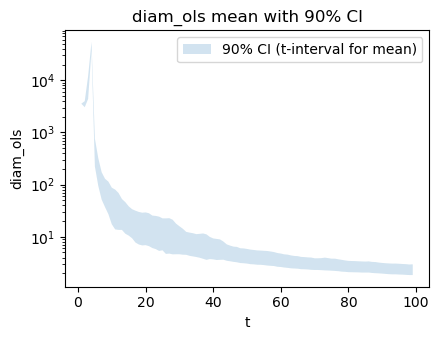

In [12]:
arr = np.asarray(diam_ols_T)
n_o = arr.shape[0]
x_o = np.arange(1, arr.shape[1] + 1)

mean_o = arr.mean(axis=0)
std_o = arr.std(axis=0, ddof=1)
se_o = std_o / np.sqrt(n_o)

tcrit_o = t.ppf(0.95, df=n-1)  # two-sided 90% => 0.95 quantile
lo_o = mean_o - tcrit_o * se_o
hi_o = mean_o + tcrit_o * se_o

plt.figure()
plt.yscale("log")
# plt.plot(x_o, mean_o, label="Mean")
plt.fill_between(x_o, lo_o, hi_o, alpha=0.2, label="90% CI (t-interval for mean)")
plt.xlabel("t")
plt.ylabel("diam_ols")
plt.title("diam_ols mean with 90% CI")
plt.legend()
plt.tight_layout()
plt.show()

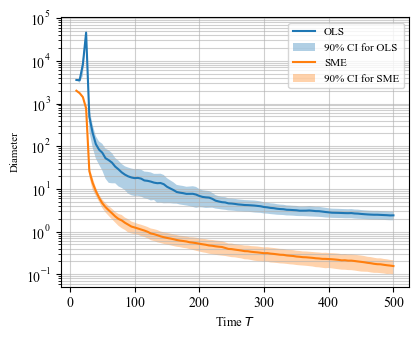

In [25]:
# plot both on the same figure
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab10.colors)
plt.rcParams["font.family"] = "Times New Roman"


plt.figure()

plt.plot(Tlist, mean_o, label="OLS")
plt.fill_between(x, lo_o, hi_o, alpha=0.35, label="90% CI for OLS")

plt.plot(x, mean, label='SME')
plt.fill_between(x, lower, upper, alpha=0.35, label='90% CI for SME')



plt.yscale("log")
plt.xlabel("Time $T$",fontsize=9)
plt.ylabel("Diameter",fontsize=8)

plt.grid(True, which="both", alpha=0.6)

plt.rcParams['figure.figsize'] = [4.5, 3.5]

plt.legend(fontsize=8)
plt.show()

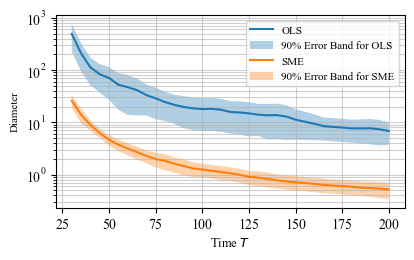

In [44]:
x = np.array(x)
mask = (x >= 40) & (x <= 350)

plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.tab10.colors)
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['figure.figsize'] = [4.5, 3.5]

mask = (x >= 30) & (x <= 200)

x_cut = x[mask]
mean_o_cut = mean_o[mask]
lo_o_cut = lo_o[mask]
hi_o_cut = hi_o[mask]

mean_cut = mean[mask]
lower_cut = lower[mask]
upper_cut = upper[mask]

plt.figure(figsize=(4.5, 2.5))
# plt.rcParams['figure.figsize'] = [5, 3.5]

plt.plot(x_cut, mean_o_cut, label="OLS")
plt.fill_between(x_cut, lo_o_cut, hi_o_cut, alpha=0.35, label="90% Error Band for OLS")

plt.plot(x_cut, mean_cut, label="SME")
plt.fill_between(x_cut, lower_cut, upper_cut, alpha=0.35, label="90% Error Band for SME")

plt.yscale("log")
plt.xlabel("Time $T$", fontsize=9)
plt.ylabel("Diameter", fontsize=8)
plt.grid(True, which="both", alpha=0.6)


plt.legend(fontsize=8)
plt.savefig("diameter_fig.pdf", bbox_inches="tight")
# plt.show()